In [ ]:
#GA and NM Hybrid

In [ ]:
#Logarithmic

Generation 1, Best Fitness: 0.5761200754217881
Generation 2, Best Fitness: 0.5881377662863099
Generation 3, Best Fitness: 0.5893457345356905
Generation 4, Best Fitness: 0.6140865031022078
Generation 5, Best Fitness: 0.62850541949981
Generation 6, Best Fitness: 0.6342502950059201
Generation 7, Best Fitness: 0.6439814660816631
Generation 8, Best Fitness: 0.6454588831992687
Generation 9, Best Fitness: 0.6495817624155226
Generation 10, Best Fitness: 0.6622826272096571
Generation 11, Best Fitness: 0.6751128427550277
Generation 12, Best Fitness: 0.6751128427550277
Generation 13, Best Fitness: 0.6751128427550277
Generation 14, Best Fitness: 0.6808361082932326
Generation 15, Best Fitness: 0.6808361082932326
Generation 16, Best Fitness: 0.6808361082932326
Generation 17, Best Fitness: 0.683259387002559
Generation 18, Best Fitness: 0.6847010151143718
Generation 19, Best Fitness: 0.7122793025632596
Generation 20, Best Fitness: 0.7122793025632596
Generation 21, Best Fitness: 0.7122793025632596
Gene

<Figure size 1200x800 with 0 Axes>

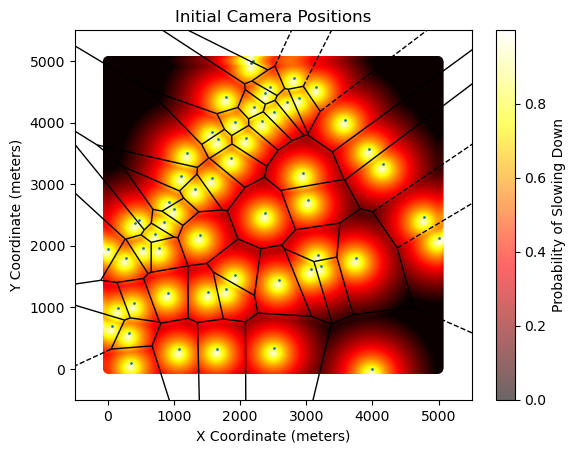

Initial Average Coverage Probability: 0.4558055255549537


<Figure size 1200x800 with 0 Axes>

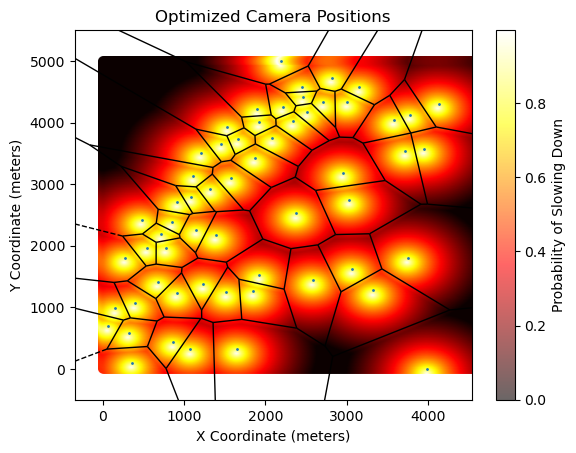

Optimized Average Coverage Probability: 0.507455328255462

Solution Improvement: 0.11331543784517206


/var/folders/vq/_4vyrs956z78dt4gf5_mzj6w0000gn/T/ipykernel_21020/2992739752.py:283: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})


Optimized Average Coverage Probability: 0.5326166554009817


<Figure size 1200x800 with 0 Axes>

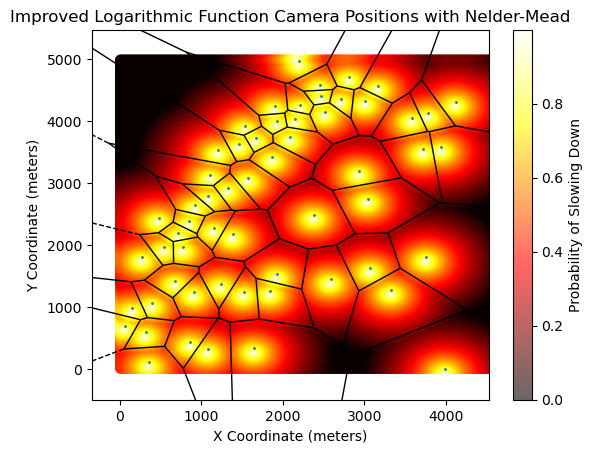

Camera Positions in Longitude and Latitude:
Camera 1: (X: -70.63, Y: -33.44)
Camera 2: (X: -70.60, Y: -33.44)
Camera 3: (X: -70.61, Y: -33.42)
Camera 4: (X: -70.60, Y: -33.42)
Camera 5: (X: -70.62, Y: -33.44)
Camera 6: (X: -70.60, Y: -33.42)
Camera 7: (X: -70.60, Y: -33.44)
Camera 8: (X: -70.62, Y: -33.42)
Camera 9: (X: -70.63, Y: -33.44)
Camera 10: (X: -70.62, Y: -33.43)
Camera 11: (X: -70.59, Y: -33.42)
Camera 12: (X: -70.60, Y: -33.42)
Camera 13: (X: -70.63, Y: -33.43)
Camera 14: (X: -70.62, Y: -33.42)
Camera 15: (X: -70.62, Y: -33.43)
Camera 16: (X: -70.63, Y: -33.44)
Camera 17: (X: -70.62, Y: -33.44)
Camera 18: (X: -70.60, Y: -33.43)
Camera 19: (X: -70.61, Y: -33.42)
Camera 20: (X: -70.61, Y: -33.42)
Camera 21: (X: -70.59, Y: -33.42)
Camera 22: (X: -70.62, Y: -33.43)
Camera 23: (X: -70.61, Y: -33.42)
Camera 24: (X: -70.62, Y: -33.42)
Camera 25: (X: -70.61, Y: -33.43)
Camera 26: (X: -70.61, Y: -33.42)
Camera 27: (X: -70.62, Y: -33.45)
Camera 28: (X: -70.62, Y: -33.44)
Camera 29: (X

<Figure size 1200x800 with 0 Axes>

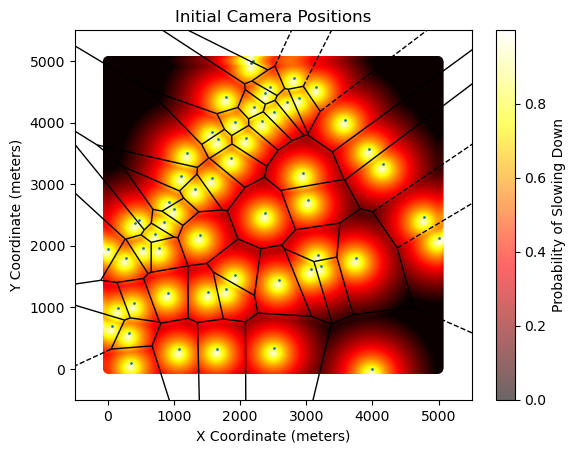

Initial Average Coverage Probability: 0.4558055255549537


<Figure size 1200x800 with 0 Axes>

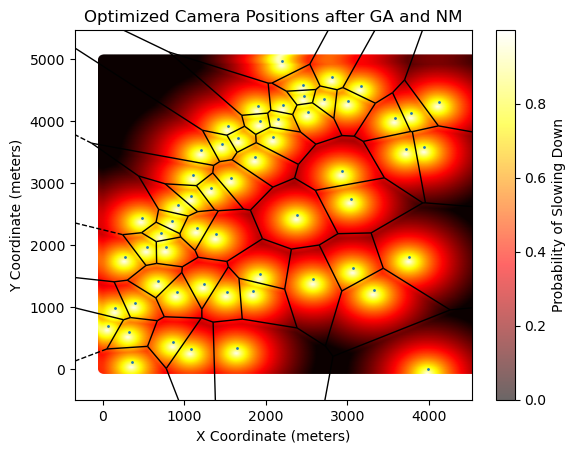

Optimized Average Coverage Probability after GA and NM: 0.5326166554009817

Solution Improvement: 0.1685173292985176
0.006057318248733119

There is a statistically significant difference in the means of the initial and final probabilities.


In [21]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
from scipy.optimize import minimize
import time
from scipy.stats import wilcoxon

# Record the start time
start_time = time.time()

# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'PROVIDENCIA']  # Filter for Providencia
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values
min_distance = 250


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]


# Initialize parameters
population_size = 300
num_generations = 300
mutation_base_rate = 0.02
crossover_rate = 0.7  # Not used in the diversified crossover
tournament_size = 10
num_parents = population_size // 2
early_stopping_rounds = 50
no_improvement_stretch = 0
best_fitness = 0

# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()

# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    k = 0.005
    probability = 1 - np.log(1 + k * dist) / np.log(1 + k * 1000)
    # Ensure the probability is never negative and does not exceed 1, applied to each element of the array
    probability = np.clip(probability, 0, 1)
    return probability

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)



def adaptive_mutation(child, base_mutation_rate, generation):
    mutation_rate = base_mutation_rate * (1 + np.exp(-0.05 * generation))
    for i in range(len(child)):
        if np.random.rand() < mutation_rate:
            child[i] = np.random.uniform(0, max(area_size), 2)
    return child


def crossover(parents, method='uniform'):
    offspring = []
    for i in range(0, len(parents), 2):
        parent1 = parents[i]
        parent2 = parents[i+1] if i+1 < len(parents) else random.choice(parents)
        child1, child2 = parent1.copy(), parent2.copy()
        
        if method == 'single-point':
            cp = np.random.randint(1, len(parent1))
            child1, child2 = np.concatenate([parent1[:cp], parent2[cp:]]), np.concatenate([parent2[:cp], parent1[cp:]])
        elif method == 'two-point':
            cp1, cp2 = sorted(np.random.choice(range(1, len(parent1)), 2, replace=False))
            child1 = np.concatenate([parent1[:cp1], parent2[cp1:cp2], parent1[cp2:]])
            child2 = np.concatenate([parent2[:cp1], parent1[cp1:cp2], parent2[cp2:]])

        offspring.extend([child1, child2])
    return offspring

def fitness_function(individual, grid_points, min_distance, penalty_scale=0.4):
    coverage = calculate_voronoi_coverage(grid_points, individual)
    penalty = 0
    num_pairs = 0

    # Calculate the reduction factor for each violating camera pair
    for i in range(len(individual)):
        for j in range(i + 1, len(individual)):
            distance = np.linalg.norm(individual[i] - individual[j])
            if distance < min_distance:
                penalty_reduction = (min_distance - distance) / min_distance
                penalty += penalty_reduction
                num_pairs += 1

    # Calculate average penalty if there are any violations
    if num_pairs > 0:
        average_penalty = penalty / num_pairs
        adjusted_coverage = coverage * (1 - penalty_scale * average_penalty)
    else:
        adjusted_coverage = coverage

    # Ensure fitness is non-negative
    fitness = max(0, adjusted_coverage)
    #print(f"Debug: Original Coverage {coverage}, Penalty {penalty}, Adjusted Coverage {adjusted_coverage}, Final Fitness {fitness}")
    return fitness




def initialize_population(pop_size, crash_points):
    population = []
    for _ in range(pop_size):
        np.random.shuffle(crash_points)
        population.append(crash_points.copy())
    return population

def calculate_fitness(population, grid_points, min_distance):
    fitness_scores = []
    for individual in population:
        fitness_scores.append(fitness_function(individual, grid_points, min_distance))
    return np.array(fitness_scores)

def tournament_selection(population, fitness_scores, num_parents):
    parents = []
    for _ in range(num_parents):
        indices = np.random.randint(len(population), size=tournament_size)
        best_index = indices[np.argmax(fitness_scores[indices])]
        parents.append(population[best_index].copy())
    return parents

def apply_crossover(parents):
    offspring = []
    for i in range(0, len(parents), 2):
        if i + 1 < len(parents):
            parent1 = parents[i]
            parent2 = parents[i + 1]
            if np.random.rand() < crossover_rate:
                crossover_method = 'single-point' if np.random.rand() < 0.5 else 'two-point'
                children = crossover([parent1, parent2], method=crossover_method)
                offspring.extend(children)
            else:
                offspring.extend([parent1, parent2])
        else:
            offspring.append(parents[i])
    return offspring

def apply_mutation(offspring, improvement_factor):
    for i in range(len(offspring)):
        offspring[i] = adaptive_mutation(offspring[i], mutation_base_rate, improvement_factor)
    return offspring

# Initialize population
population = initialize_population(population_size, scaled_crash_points)

# Main GA loop
for generation in range(num_generations):
    fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
    current_best = np.max(fitness_scores)
    
    if current_best > best_fitness:
        best_fitness = current_best
        no_improvement_stretch = 0
    else:
        no_improvement_stretch += 1
    
    if no_improvement_stretch >= early_stopping_rounds:
        print(f"Early stopping after {generation} generations.")
        break
    
    parents = tournament_selection(population, fitness_scores, num_parents)
    offspring = apply_crossover(parents)
    improvement_factor = (best_fitness - current_best) / best_fitness if best_fitness != 0 else 0
    offspring = apply_mutation(offspring, improvement_factor)
    population = parents + offspring

    print(f"Generation {generation + 1}, Best Fitness: {best_fitness}")

# Determine the best solution
final_fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
best_index = np.argmax(final_fitness_scores)
best_solution = population[best_index]

# Print the final best solution and its fitness
print("Best Solution Fitness:", final_fitness_scores[best_index])

#-----------------------------------------------------------------------------------------------


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, best_solution)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(best_solution, probabilities, 'Optimized Camera Positions')
final_avg_probability = calculate_voronoi_coverage(grid_points, best_solution)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, best_solution, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

# Record the start time
start_time = time.time()

# Initialize camera positions with scaled crash points
camera_positions = best_solution

# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
ga_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
ga_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)


# Objective function to maximize the average probability of slowing down
def objective_function(camera_positions_flat, grid_points, area_size):
    camera_positions = camera_positions_flat.reshape(-1, 2)
    # Calculate the average coverage using the existing `calculate_voronoi_coverage` function
    negative_avg_probability = -calculate_voronoi_coverage(grid_points, camera_positions)
    return negative_avg_probability

# Function to optimize camera positions using the Nelder-Mead algorithm
def optimize_camera_positions_nelder_mead(initial_camera_positions, grid_points, area_size):
    # Flatten the initial_camera_positions for the optimizer
    initial_positions_flat = initial_camera_positions.flatten()
    # Run the Nelder-Mead optimization
    result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})
    # Reshape the result to the original shape
    optimized_positions = result.x.reshape(-1, 2)
    return optimized_positions

# Example of optimizing camera positions
optimized_camera_positions = optimize_camera_positions_nelder_mead(camera_positions, grid_points, area_size)

# After optimization, you can calculate the average probability and plot the results as before
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")

# Plot the optimized camera positions
probabilities = probability_of_slowing(np.min(pairwise_distances(grid_points, optimized_camera_positions), axis=1))
plot_voronoi(optimized_camera_positions, probabilities, 'Improved Logarithmic Function Camera Positions with Nelder-Mead')

# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

# Save to CSV
#output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V2/Nelder-Mead/N_M_Lin.csv'  # Adjust the path as necessary
#camera_positions_df.to_csv(output_csv_path, index=False)

#print(f"Camera positions saved to {output_csv_path}")

# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")

#Nelder-Mead Optimization after GA----------------------------------------------------------------------
camera_positions = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, optimized_camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(optimized_camera_positions, probabilities, 'Optimized Camera Positions after GA and NM')
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability after GA and NM: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

data = {
        'Initial_X': camera_positions[:, 0],
        'Initial_Y': camera_positions[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': optimized_camera_positions[:, 0],
        'Final_Y': optimized_camera_positions[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")

else:
    print("There is no statistically significant difference in the means of the initial and final probabilities.")

output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Providencia/Hybrid1_Log_Provi_Positions.csv'  # Adjust the path as necessary
camera_positions_df.to_csv(output_csv_path, index=False)
output_csv_path2 = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Providencia/Hybrid1_Log_Provi_HT.csv'  # Adjust the path as necessary
comparison_df.to_csv(output_csv_path2, index=False)


In [ ]:
#Linear

Generation 1, Best Fitness: 0.6106826522739482
Generation 2, Best Fitness: 0.6300452188834307
Generation 3, Best Fitness: 0.6329959184065477
Generation 4, Best Fitness: 0.6633176844577586
Generation 5, Best Fitness: 0.6754522621388999
Generation 6, Best Fitness: 0.6786707852196379
Generation 7, Best Fitness: 0.7063779453398686
Generation 8, Best Fitness: 0.7063779453398686
Generation 9, Best Fitness: 0.7122419390029358
Generation 10, Best Fitness: 0.7122419390029358
Generation 11, Best Fitness: 0.7122419390029358
Generation 12, Best Fitness: 0.722716667688736
Generation 13, Best Fitness: 0.722716667688736
Generation 14, Best Fitness: 0.722716667688736
Generation 15, Best Fitness: 0.722716667688736
Generation 16, Best Fitness: 0.722716667688736
Generation 17, Best Fitness: 0.7230304958450516
Generation 18, Best Fitness: 0.7230304958450516
Generation 19, Best Fitness: 0.7386648015293603
Generation 20, Best Fitness: 0.7386648015293603
Generation 21, Best Fitness: 0.7386648015293603
Genera

<Figure size 1200x800 with 0 Axes>

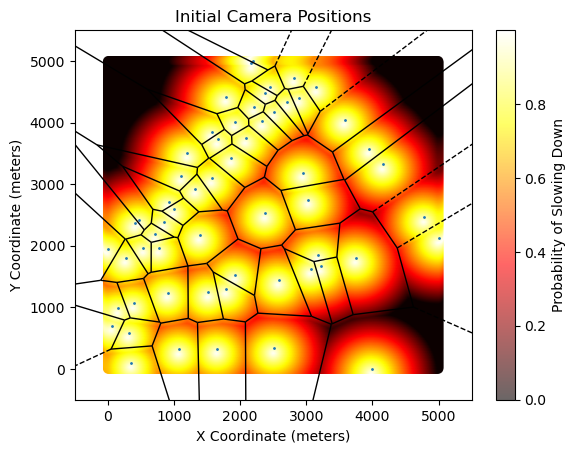

Initial Average Coverage Probability: 0.6267869728205457


<Figure size 1200x800 with 0 Axes>

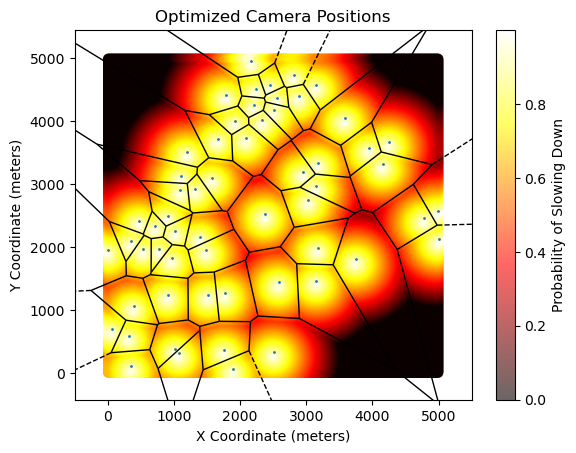

Optimized Average Coverage Probability: 0.6867515828830961

Solution Improvement: 0.09566984105095423


/var/folders/vq/_4vyrs956z78dt4gf5_mzj6w0000gn/T/ipykernel_21020/1361434100.py:285: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})


Optimized Average Coverage Probability: 0.7106033675029514


<Figure size 1200x800 with 0 Axes>

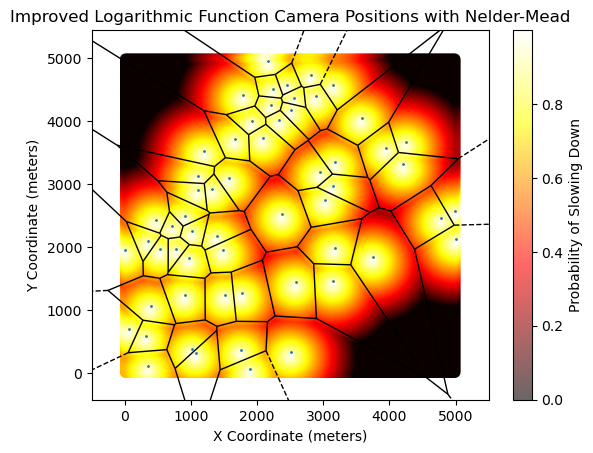

Camera Positions in Longitude and Latitude:
Camera 1: (X: -70.60, Y: -33.42)
Camera 2: (X: -70.61, Y: -33.42)
Camera 3: (X: -70.60, Y: -33.43)
Camera 4: (X: -70.63, Y: -33.44)
Camera 5: (X: -70.62, Y: -33.44)
Camera 6: (X: -70.62, Y: -33.43)
Camera 7: (X: -70.62, Y: -33.42)
Camera 8: (X: -70.60, Y: -33.43)
Camera 9: (X: -70.58, Y: -33.43)
Camera 10: (X: -70.60, Y: -33.44)
Camera 11: (X: -70.61, Y: -33.43)
Camera 12: (X: -70.62, Y: -33.43)
Camera 13: (X: -70.58, Y: -33.43)
Camera 14: (X: -70.60, Y: -33.42)
Camera 15: (X: -70.60, Y: -33.42)
Camera 16: (X: -70.62, Y: -33.45)
Camera 17: (X: -70.63, Y: -33.43)
Camera 18: (X: -70.63, Y: -33.43)
Camera 19: (X: -70.62, Y: -33.44)
Camera 20: (X: -70.62, Y: -33.45)
Camera 21: (X: -70.60, Y: -33.42)
Camera 22: (X: -70.61, Y: -33.44)
Camera 23: (X: -70.62, Y: -33.43)
Camera 24: (X: -70.61, Y: -33.42)
Camera 25: (X: -70.61, Y: -33.42)
Camera 26: (X: -70.60, Y: -33.43)
Camera 27: (X: -70.63, Y: -33.43)
Camera 28: (X: -70.63, Y: -33.44)
Camera 29: (X

<Figure size 1200x800 with 0 Axes>

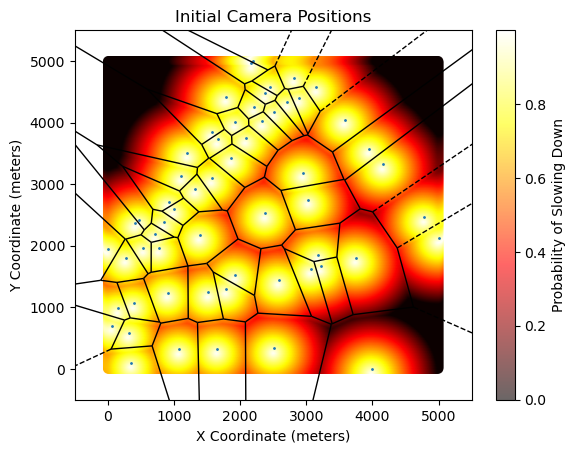

Initial Average Coverage Probability: 0.6267869728205457


<Figure size 1200x800 with 0 Axes>

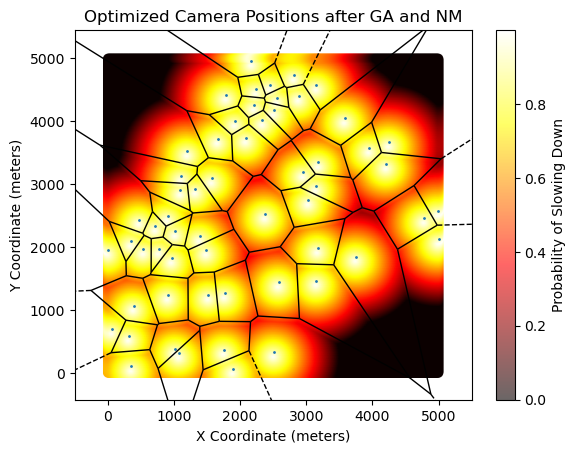

Optimized Average Coverage Probability after GA and NM: 0.7106033675029514

Solution Improvement: 0.13372389394953646
0.021698409147981424

There is a statistically significant difference in the means of the initial and final probabilities.


In [22]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
from scipy.optimize import minimize
import time
from scipy.stats import wilcoxon

# Record the start time
start_time = time.time()

# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'PROVIDENCIA']  # Filter for Providencia
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values
min_distance = 250


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]


# Initialize parameters
population_size = 300
num_generations = 300
mutation_base_rate = 0.02
crossover_rate = 0.7  # Not used in the diversified crossover
tournament_size = 10
num_parents = population_size // 2
early_stopping_rounds = 50
no_improvement_stretch = 0
best_fitness = 0

# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()

# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    # Linear function parameters as solved previously
    a = -1/1000
    b = 1
    probability = a * dist + b
    # Ensure the probability is never negative, applied to each element of the array
    probability = np.maximum(probability, 0)
    return probability

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)



def adaptive_mutation(child, base_mutation_rate, generation):
    mutation_rate = base_mutation_rate * (1 + np.exp(-0.05 * generation))
    for i in range(len(child)):
        if np.random.rand() < mutation_rate:
            child[i] = np.random.uniform(0, max(area_size), 2)
    return child


def crossover(parents, method='uniform'):
    offspring = []
    for i in range(0, len(parents), 2):
        parent1 = parents[i]
        parent2 = parents[i+1] if i+1 < len(parents) else random.choice(parents)
        child1, child2 = parent1.copy(), parent2.copy()
        
        if method == 'single-point':
            cp = np.random.randint(1, len(parent1))
            child1, child2 = np.concatenate([parent1[:cp], parent2[cp:]]), np.concatenate([parent2[:cp], parent1[cp:]])
        elif method == 'two-point':
            cp1, cp2 = sorted(np.random.choice(range(1, len(parent1)), 2, replace=False))
            child1 = np.concatenate([parent1[:cp1], parent2[cp1:cp2], parent1[cp2:]])
            child2 = np.concatenate([parent2[:cp1], parent1[cp1:cp2], parent2[cp2:]])

        offspring.extend([child1, child2])
    return offspring

def fitness_function(individual, grid_points, min_distance, penalty_scale=0.4):
    coverage = calculate_voronoi_coverage(grid_points, individual)
    penalty = 0
    num_pairs = 0

    # Calculate the reduction factor for each violating camera pair
    for i in range(len(individual)):
        for j in range(i + 1, len(individual)):
            distance = np.linalg.norm(individual[i] - individual[j])
            if distance < min_distance:
                penalty_reduction = (min_distance - distance) / min_distance
                penalty += penalty_reduction
                num_pairs += 1

    # Calculate average penalty if there are any violations
    if num_pairs > 0:
        average_penalty = penalty / num_pairs
        adjusted_coverage = coverage * (1 - penalty_scale * average_penalty)
    else:
        adjusted_coverage = coverage

    # Ensure fitness is non-negative
    fitness = max(0, adjusted_coverage)
    #print(f"Debug: Original Coverage {coverage}, Penalty {penalty}, Adjusted Coverage {adjusted_coverage}, Final Fitness {fitness}")
    return fitness




def initialize_population(pop_size, crash_points):
    population = []
    for _ in range(pop_size):
        np.random.shuffle(crash_points)
        population.append(crash_points.copy())
    return population

def calculate_fitness(population, grid_points, min_distance):
    fitness_scores = []
    for individual in population:
        fitness_scores.append(fitness_function(individual, grid_points, min_distance))
    return np.array(fitness_scores)

def tournament_selection(population, fitness_scores, num_parents):
    parents = []
    for _ in range(num_parents):
        indices = np.random.randint(len(population), size=tournament_size)
        best_index = indices[np.argmax(fitness_scores[indices])]
        parents.append(population[best_index].copy())
    return parents

def apply_crossover(parents):
    offspring = []
    for i in range(0, len(parents), 2):
        if i + 1 < len(parents):
            parent1 = parents[i]
            parent2 = parents[i + 1]
            if np.random.rand() < crossover_rate:
                crossover_method = 'single-point' if np.random.rand() < 0.5 else 'two-point'
                children = crossover([parent1, parent2], method=crossover_method)
                offspring.extend(children)
            else:
                offspring.extend([parent1, parent2])
        else:
            offspring.append(parents[i])
    return offspring

def apply_mutation(offspring, improvement_factor):
    for i in range(len(offspring)):
        offspring[i] = adaptive_mutation(offspring[i], mutation_base_rate, improvement_factor)
    return offspring

# Initialize population
population = initialize_population(population_size, scaled_crash_points)

# Main GA loop
for generation in range(num_generations):
    fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
    current_best = np.max(fitness_scores)
    
    if current_best > best_fitness:
        best_fitness = current_best
        no_improvement_stretch = 0
    else:
        no_improvement_stretch += 1
    
    if no_improvement_stretch >= early_stopping_rounds:
        print(f"Early stopping after {generation} generations.")
        break
    
    parents = tournament_selection(population, fitness_scores, num_parents)
    offspring = apply_crossover(parents)
    improvement_factor = (best_fitness - current_best) / best_fitness if best_fitness != 0 else 0
    offspring = apply_mutation(offspring, improvement_factor)
    population = parents + offspring

    print(f"Generation {generation + 1}, Best Fitness: {best_fitness}")

# Determine the best solution
final_fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
best_index = np.argmax(final_fitness_scores)
best_solution = population[best_index]

# Print the final best solution and its fitness
print("Best Solution Fitness:", final_fitness_scores[best_index])

#-----------------------------------------------------------------------------------------------


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, best_solution)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(best_solution, probabilities, 'Optimized Camera Positions')
final_avg_probability = calculate_voronoi_coverage(grid_points, best_solution)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, best_solution, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

# Record the start time
start_time = time.time()

# Initialize camera positions with scaled crash points
camera_positions = best_solution

# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
ga_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
ga_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)


# Objective function to maximize the average probability of slowing down
def objective_function(camera_positions_flat, grid_points, area_size):
    camera_positions = camera_positions_flat.reshape(-1, 2)
    # Calculate the average coverage using the existing `calculate_voronoi_coverage` function
    negative_avg_probability = -calculate_voronoi_coverage(grid_points, camera_positions)
    return negative_avg_probability

# Function to optimize camera positions using the Nelder-Mead algorithm
def optimize_camera_positions_nelder_mead(initial_camera_positions, grid_points, area_size):
    # Flatten the initial_camera_positions for the optimizer
    initial_positions_flat = initial_camera_positions.flatten()
    # Run the Nelder-Mead optimization
    result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})
    # Reshape the result to the original shape
    optimized_positions = result.x.reshape(-1, 2)
    return optimized_positions

# Example of optimizing camera positions
optimized_camera_positions = optimize_camera_positions_nelder_mead(camera_positions, grid_points, area_size)

# After optimization, you can calculate the average probability and plot the results as before
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")

# Plot the optimized camera positions
probabilities = probability_of_slowing(np.min(pairwise_distances(grid_points, optimized_camera_positions), axis=1))
plot_voronoi(optimized_camera_positions, probabilities, 'Improved Logarithmic Function Camera Positions with Nelder-Mead')

# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

# Save to CSV
#output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V2/Nelder-Mead/N_M_Lin.csv'  # Adjust the path as necessary
#camera_positions_df.to_csv(output_csv_path, index=False)

#print(f"Camera positions saved to {output_csv_path}")

# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")

#Nelder-Mead Optimization after GA----------------------------------------------------------------------
camera_positions = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, optimized_camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(optimized_camera_positions, probabilities, 'Optimized Camera Positions after GA and NM')
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability after GA and NM: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

data = {
        'Initial_X': camera_positions[:, 0],
        'Initial_Y': camera_positions[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': optimized_camera_positions[:, 0],
        'Final_Y': optimized_camera_positions[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")
    output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Providencia/Hybrid1_Lin_Provi_Positions.csv'  # Adjust the path as necessary
    camera_positions_df.to_csv(output_csv_path, index=False)
    output_csv_path2 = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Providencia/Hybrid1_Lin_Provi_HT.csv'  # Adjust the path as necessary
    comparison_df.to_csv(output_csv_path2, index=False)

else:
    print("There is no statistically significant difference in the means of the initial and final probabilities.")


In [ ]:
#Quadratic

Generation 1, Best Fitness: 0.6437293796771879
Generation 2, Best Fitness: 0.7079876612848502
Generation 3, Best Fitness: 0.7143532655000979
Generation 4, Best Fitness: 0.7446655185997865
Generation 5, Best Fitness: 0.7594371756527792
Generation 6, Best Fitness: 0.7639085377027551
Generation 7, Best Fitness: 0.7742432984509786
Generation 8, Best Fitness: 0.7744693372627586
Generation 9, Best Fitness: 0.7811946868553633
Generation 10, Best Fitness: 0.7811946868553633
Generation 11, Best Fitness: 0.7895084255592422
Generation 12, Best Fitness: 0.7945025667745867
Generation 13, Best Fitness: 0.8053742248492133
Generation 14, Best Fitness: 0.8053742248492133
Generation 15, Best Fitness: 0.8053742248492133
Generation 16, Best Fitness: 0.8087934034054629
Generation 17, Best Fitness: 0.8104208567363482
Generation 18, Best Fitness: 0.8129667120596333
Generation 19, Best Fitness: 0.8174274153659494
Generation 20, Best Fitness: 0.8174274153659494
Generation 21, Best Fitness: 0.84228536226262
Gen

<Figure size 1200x800 with 0 Axes>

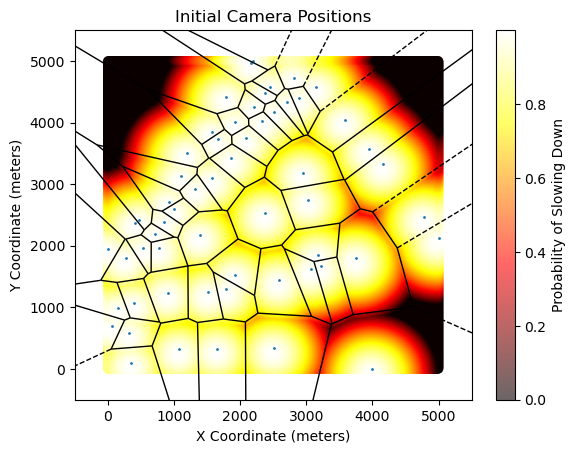

Initial Average Coverage Probability: 0.8054848220384362


<Figure size 1200x800 with 0 Axes>

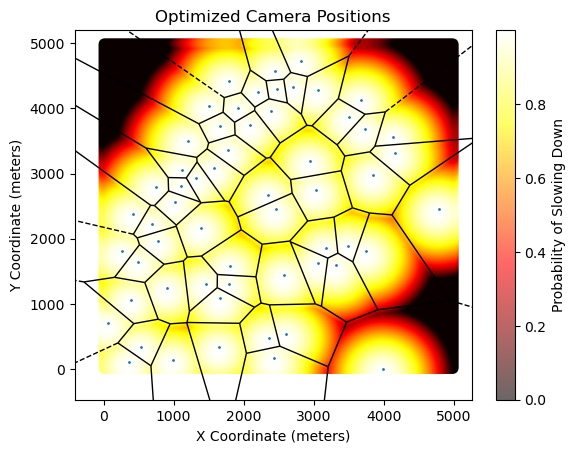

Optimized Average Coverage Probability: 0.8708270188201621

Solution Improvement: 0.08112157422949916


/var/folders/vq/_4vyrs956z78dt4gf5_mzj6w0000gn/T/ipykernel_21020/2330629137.py:284: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})


Optimized Average Coverage Probability: 0.8854692804108769


<Figure size 1200x800 with 0 Axes>

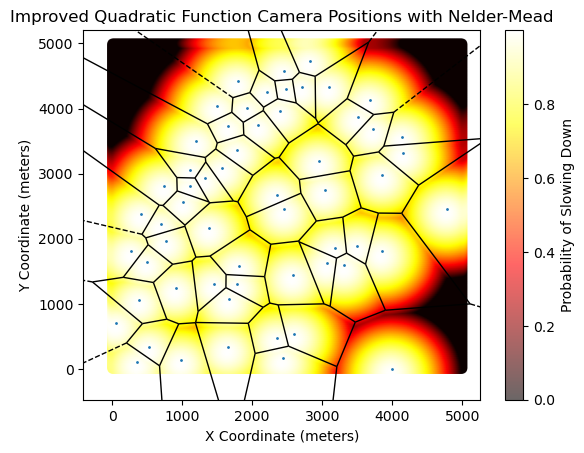

Camera Positions in Longitude and Latitude:
Camera 1: (X: -70.63, Y: -33.44)
Camera 2: (X: -70.62, Y: -33.44)
Camera 3: (X: -70.60, Y: -33.42)
Camera 4: (X: -70.60, Y: -33.44)
Camera 5: (X: -70.63, Y: -33.43)
Camera 6: (X: -70.61, Y: -33.42)
Camera 7: (X: -70.62, Y: -33.43)
Camera 8: (X: -70.60, Y: -33.42)
Camera 9: (X: -70.62, Y: -33.43)
Camera 10: (X: -70.63, Y: -33.45)
Camera 11: (X: -70.60, Y: -33.42)
Camera 12: (X: -70.62, Y: -33.44)
Camera 13: (X: -70.62, Y: -33.43)
Camera 14: (X: -70.62, Y: -33.43)
Camera 15: (X: -70.59, Y: -33.43)
Camera 16: (X: -70.63, Y: -33.44)
Camera 17: (X: -70.60, Y: -33.44)
Camera 18: (X: -70.61, Y: -33.43)
Camera 19: (X: -70.62, Y: -33.45)
Camera 20: (X: -70.61, Y: -33.45)
Camera 21: (X: -70.63, Y: -33.44)
Camera 22: (X: -70.62, Y: -33.42)
Camera 23: (X: -70.61, Y: -33.42)
Camera 24: (X: -70.59, Y: -33.43)
Camera 25: (X: -70.63, Y: -33.43)
Camera 26: (X: -70.62, Y: -33.42)
Camera 27: (X: -70.58, Y: -33.43)
Camera 28: (X: -70.62, Y: -33.45)
Camera 29: (X

<Figure size 1200x800 with 0 Axes>

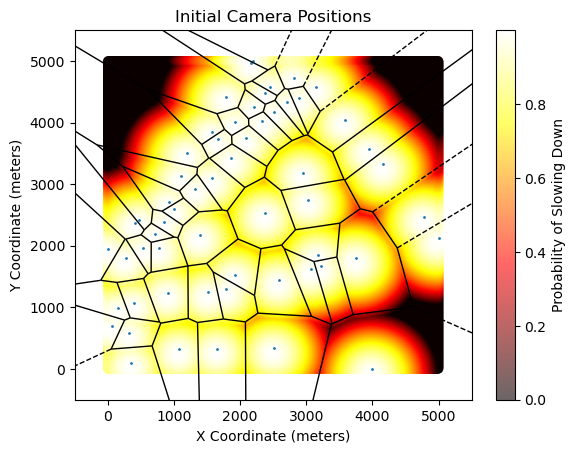

Initial Average Coverage Probability: 0.8054848220384362


<Figure size 1200x800 with 0 Axes>

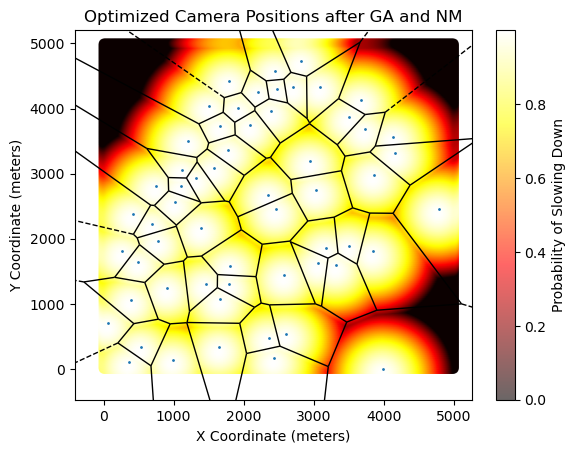

Optimized Average Coverage Probability after GA and NM: 0.8854692804108769

Solution Improvement: 0.09929977100005992
0.004657300656924901

There is a statistically significant difference in the means of the initial and final probabilities.


In [24]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
from scipy.optimize import minimize
import time
from scipy.stats import wilcoxon

# Record the start time
start_time = time.time()

# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'PROVIDENCIA']  # Filter for Providencia
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values
min_distance = 250


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]


# Initialize parameters
population_size = 300
num_generations = 500
mutation_base_rate = 0.02
crossover_rate = 0.7  # Not used in the diversified crossover
tournament_size = 10
num_parents = population_size // 2
early_stopping_rounds = 50
no_improvement_stretch = 0
best_fitness = 0

# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()

# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    a = -1/1000**2
    c = 1
    probability = a * dist**2 + c
    # Ensure the probability is never negative, applied to each element of the array
    probability = np.maximum(probability, 0)
    return probability

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)



def adaptive_mutation(child, base_mutation_rate, generation):
    mutation_rate = base_mutation_rate * (1 + np.exp(-0.05 * generation))
    for i in range(len(child)):
        if np.random.rand() < mutation_rate:
            child[i] = np.random.uniform(0, max(area_size), 2)
    return child


def crossover(parents, method='uniform'):
    offspring = []
    for i in range(0, len(parents), 2):
        parent1 = parents[i]
        parent2 = parents[i+1] if i+1 < len(parents) else random.choice(parents)
        child1, child2 = parent1.copy(), parent2.copy()
        
        if method == 'single-point':
            cp = np.random.randint(1, len(parent1))
            child1, child2 = np.concatenate([parent1[:cp], parent2[cp:]]), np.concatenate([parent2[:cp], parent1[cp:]])
        elif method == 'two-point':
            cp1, cp2 = sorted(np.random.choice(range(1, len(parent1)), 2, replace=False))
            child1 = np.concatenate([parent1[:cp1], parent2[cp1:cp2], parent1[cp2:]])
            child2 = np.concatenate([parent2[:cp1], parent1[cp1:cp2], parent2[cp2:]])

        offspring.extend([child1, child2])
    return offspring

def fitness_function(individual, grid_points, min_distance, penalty_scale=0.4):
    coverage = calculate_voronoi_coverage(grid_points, individual)
    penalty = 0
    num_pairs = 0

    # Calculate the reduction factor for each violating camera pair
    for i in range(len(individual)):
        for j in range(i + 1, len(individual)):
            distance = np.linalg.norm(individual[i] - individual[j])
            if distance < min_distance:
                penalty_reduction = (min_distance - distance) / min_distance
                penalty += penalty_reduction
                num_pairs += 1

    # Calculate average penalty if there are any violations
    if num_pairs > 0:
        average_penalty = penalty / num_pairs
        adjusted_coverage = coverage * (1 - penalty_scale * average_penalty)
    else:
        adjusted_coverage = coverage

    # Ensure fitness is non-negative
    fitness = max(0, adjusted_coverage)
    #print(f"Debug: Original Coverage {coverage}, Penalty {penalty}, Adjusted Coverage {adjusted_coverage}, Final Fitness {fitness}")
    return fitness




def initialize_population(pop_size, crash_points):
    population = []
    for _ in range(pop_size):
        np.random.shuffle(crash_points)
        population.append(crash_points.copy())
    return population

def calculate_fitness(population, grid_points, min_distance):
    fitness_scores = []
    for individual in population:
        fitness_scores.append(fitness_function(individual, grid_points, min_distance))
    return np.array(fitness_scores)

def tournament_selection(population, fitness_scores, num_parents):
    parents = []
    for _ in range(num_parents):
        indices = np.random.randint(len(population), size=tournament_size)
        best_index = indices[np.argmax(fitness_scores[indices])]
        parents.append(population[best_index].copy())
    return parents

def apply_crossover(parents):
    offspring = []
    for i in range(0, len(parents), 2):
        if i + 1 < len(parents):
            parent1 = parents[i]
            parent2 = parents[i + 1]
            if np.random.rand() < crossover_rate:
                crossover_method = 'single-point' if np.random.rand() < 0.5 else 'two-point'
                children = crossover([parent1, parent2], method=crossover_method)
                offspring.extend(children)
            else:
                offspring.extend([parent1, parent2])
        else:
            offspring.append(parents[i])
    return offspring

def apply_mutation(offspring, improvement_factor):
    for i in range(len(offspring)):
        offspring[i] = adaptive_mutation(offspring[i], mutation_base_rate, improvement_factor)
    return offspring

# Initialize population
population = initialize_population(population_size, scaled_crash_points)

# Main GA loop
for generation in range(num_generations):
    fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
    current_best = np.max(fitness_scores)
    
    if current_best > best_fitness:
        best_fitness = current_best
        no_improvement_stretch = 0
    else:
        no_improvement_stretch += 1
    
    if no_improvement_stretch >= early_stopping_rounds:
        print(f"Early stopping after {generation} generations.")
        break
    
    parents = tournament_selection(population, fitness_scores, num_parents)
    offspring = apply_crossover(parents)
    improvement_factor = (best_fitness - current_best) / best_fitness if best_fitness != 0 else 0
    offspring = apply_mutation(offspring, improvement_factor)
    population = parents + offspring

    print(f"Generation {generation + 1}, Best Fitness: {best_fitness}")

# Determine the best solution
final_fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
best_index = np.argmax(final_fitness_scores)
best_solution = population[best_index]

# Print the final best solution and its fitness
print("Best Solution Fitness:", final_fitness_scores[best_index])

#-----------------------------------------------------------------------------------------------


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, best_solution)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(best_solution, probabilities, 'Optimized Camera Positions')
final_avg_probability = calculate_voronoi_coverage(grid_points, best_solution)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, best_solution, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

# Record the start time
start_time = time.time()

# Initialize camera positions with scaled crash points
camera_positions = best_solution

# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
ga_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
ga_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)


# Objective function to maximize the average probability of slowing down
def objective_function(camera_positions_flat, grid_points, area_size):
    camera_positions = camera_positions_flat.reshape(-1, 2)
    # Calculate the average coverage using the existing `calculate_voronoi_coverage` function
    negative_avg_probability = -calculate_voronoi_coverage(grid_points, camera_positions)
    return negative_avg_probability

# Function to optimize camera positions using the Nelder-Mead algorithm
def optimize_camera_positions_nelder_mead(initial_camera_positions, grid_points, area_size):
    # Flatten the initial_camera_positions for the optimizer
    initial_positions_flat = initial_camera_positions.flatten()
    # Run the Nelder-Mead optimization
    result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})
    # Reshape the result to the original shape
    optimized_positions = result.x.reshape(-1, 2)
    return optimized_positions

# Example of optimizing camera positions
optimized_camera_positions = optimize_camera_positions_nelder_mead(camera_positions, grid_points, area_size)

# After optimization, you can calculate the average probability and plot the results as before
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")

# Plot the optimized camera positions
probabilities = probability_of_slowing(np.min(pairwise_distances(grid_points, optimized_camera_positions), axis=1))
plot_voronoi(optimized_camera_positions, probabilities, 'Improved Quadratic Function Camera Positions with Nelder-Mead')

# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

# Save to CSV
#output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V2/Nelder-Mead/N_M_Lin.csv'  # Adjust the path as necessary
#camera_positions_df.to_csv(output_csv_path, index=False)

#print(f"Camera positions saved to {output_csv_path}")

# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")

#Nelder-Mead Optimization after GA----------------------------------------------------------------------
camera_positions = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, optimized_camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(optimized_camera_positions, probabilities, 'Optimized Camera Positions after GA and NM')
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability after GA and NM: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

data = {
        'Initial_X': camera_positions[:, 0],
        'Initial_Y': camera_positions[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': optimized_camera_positions[:, 0],
        'Final_Y': optimized_camera_positions[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")
    output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Providencia/Hybrid1_Quad_Provi_Positions.csv'  # Adjust the path as necessary
    camera_positions_df.to_csv(output_csv_path, index=False)
    output_csv_path2 = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Providencia/Hybrid1_Quad_Provi_HT.csv'  # Adjust the path as necessary
    comparison_df.to_csv(output_csv_path2, index=False)

else:
    print("There is no statistically significant difference in the means of the initial and final probabilities.")


In [ ]:
#ORIGINAL GA WITH NM------------------------------------------

<Figure size 1200x800 with 0 Axes>

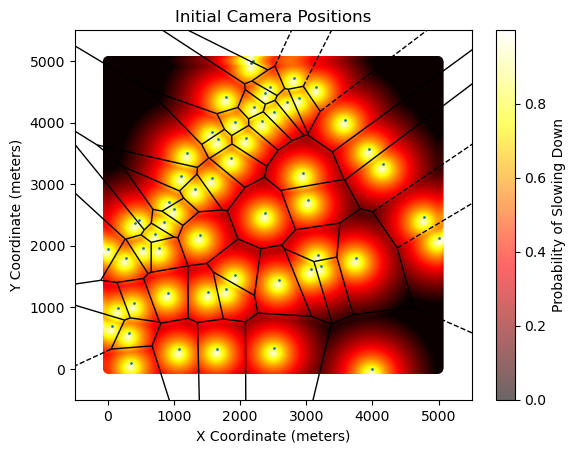

Initial Average Coverage Probability: 0.4558055255549537
Generation 1, Best Fitness: 0.4453597341929889
Generation 2, Best Fitness: 0.4772169257573444
Generation 3, Best Fitness: 0.4772169257573444
Generation 4, Best Fitness: 0.48600212566719814
Generation 5, Best Fitness: 0.48899935952791956
Generation 6, Best Fitness: 0.48899935952791956


KeyboardInterrupt: 

In [20]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
import time
from scipy.optimize import minimize
from scipy.stats import wilcoxon

# Record the start time
start_time = time.time()

# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'PROVIDENCIA']  # Filter for Providencia
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values
min_distance = 250


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points

#Crash Data Untouchable Cameras by accident numbers
fixed_cameras_mask = siniestros >= 8
fixed_cameras = scaled_crash_points[fixed_cameras_mask]


# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    k = 0.005
    probability = 1 - np.log(1 + k * dist) / np.log(1 + k * 1000)
    # Ensure the probability is never negative and does not exceed 1, applied to each element of the array
    probability = np.clip(probability, 0, 1)
    return probability

# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)
        
# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

# Fitness Function
def fitness_function(individual, grid_points):
    return calculate_voronoi_coverage(grid_points, individual)

# Selection - Tournament Selection
def select_parents(population, fitness, num_parents):
    parents = []
    for _ in range(num_parents):
        tournament = np.random.choice(len(population), size=tournament_size)
        fittest_individual = tournament[np.argmax(fitness[tournament])]
        parents.append(population[fittest_individual])
    return parents

# Crossover - Uniform Crossover
def crossover(parents, crossover_rate):
    offspring = []
    for _ in range(int(len(parents)/2)):
        parent1, parent2 = random.sample(parents, 2)
        child1, child2 = parent1.copy(), parent2.copy()
        for i in range(len(parent1)):
            if np.random.rand() < crossover_rate:
                child1[i], child2[i] = child2[i], child1[i]
        offspring.extend([child1, child2])
    return offspring

# Function to enforce minimum distance between cameras after mutation and crossover
def enforce_minimum_distance(cameras, min_distance):
    for i in range(len(cameras)):
        for j in range(i+1, len(cameras)):
            while np.linalg.norm(cameras[i] - cameras[j]) < min_distance or is_inside_triangle(cameras[j], v1, v2, v3):
                cameras[j] = np.random.uniform(0, max(area_size), 2)
                while is_inside_triangle(cameras[j], v1, v2, v3):
                    cameras[j] = np.random.uniform(0, max(area_size), 2)
    return cameras

def is_inside_triangle(pt, v1, v2, v3):
    """
    Check if point pt (x,y) is inside the triangle defined by points
    v1, v2, and v3 using barycentric coordinates.
    """
    def sign(p1, p2, p3):
        return (p1[0] - p3[0]) * (p2[1] - p3[1]) - (p2[0] - p3[0]) * (p1[1] - p3[1])

    b1 = sign(pt, v1, v2) < 0.0
    b2 = sign(pt, v2, v3) < 0.0
    b3 = sign(pt, v3, v1) < 0.0

    return ((b1 == b2) and (b2 == b3))

# Triangle vertices
v1 = (0, 3000)
v2 = (0, 5000)
v3 = (2000, 5000)


def initialize_population_with_fixed(pop_size, crash_points, fixed_cameras):
    population = []
    for _ in range(pop_size):
        variable_cameras = []
        while len(variable_cameras) < len(crash_points) - len(fixed_cameras):
            potential_point = crash_points[np.random.choice(crash_points.shape[0]), :]
            if not is_inside_triangle(potential_point, v1, v2, v3):
                variable_cameras.append(potential_point)
        variable_cameras = np.array(variable_cameras)
        individual = np.vstack((variable_cameras, fixed_cameras))
        np.random.shuffle(individual)
        population.append(individual)
    return population

# Modify the mutation function to avoid mutating fixed cameras
def mutation_with_fixed(offspring, mutation_rate, crash_points, area_size, fixed_cameras):
    for child in offspring:
        for i in range(len(child)):
            if np.random.rand() < mutation_rate and not np.any(np.all(child[i] == fixed_cameras, axis=1)):
                valid_point = False
                while not valid_point:
                    potential_point = crash_points[np.random.choice(crash_points.shape[0]), :]
                    if (0 <= potential_point[0] <= area_size[0] and
                        0 <= potential_point[1] <= area_size[1] and
                        not is_inside_triangle(potential_point, v1, v2, v3)):
                        valid_point = True
                child[i] = potential_point
    return offspring

# Genetic algorithm adjustment to include fixed cameras in the initial population
def genetic_algorithm_with_fixed(crash_points, grid_points, num_generations, population_size, fixed_cameras, initial_cameras=None):
    if initial_cameras is None:
        population = initialize_population_with_fixed(population_size, crash_points, fixed_cameras)
    else:
        # Adjust to start with the provided initial camera positions, mixing them with random selections for diversity
        population = [initial_cameras] + [np.vstack([initial_cameras, crash_points[np.random.choice(crash_points.shape[0], size=1, replace=False)]]) for _ in range(population_size - 1)]

    best_fitness = 0
    rounds_without_improvement = 0

    for generation in range(num_generations):
        fitness = np.array([fitness_function(individual, grid_points) for individual in population])
        best_fitness_generation = np.max(fitness)
        if best_fitness_generation > best_fitness:
            best_fitness = best_fitness_generation
            rounds_without_improvement = 0
        else:
            rounds_without_improvement += 1

        if rounds_without_improvement >= early_stopping_rounds:
            print(f"Early stopping triggered after {generation + 1} generations.")
            break

        parents = select_parents(population, fitness, num_parents)
        offspring = crossover(parents, crossover_rate)
        offspring = mutation_with_fixed(offspring, mutation_rate, crash_points, area_size, fixed_cameras)
        offspring = [enforce_minimum_distance(child, min_distance) for child in offspring]  # Apply minimum distance enforcement
        population = parents + offspring

        print(f"Generation {generation + 1}, Best Fitness: {best_fitness}")

    best_index = np.argmax([fitness_function(ind, grid_points) for ind in population])
    return population[best_index]

# GA Parameters configuration ORIGINALS
#population_size = 200  # Adjust as necessary
#num_generations = 100  # Adjust as necessary
#crossover_rate = 0.7  # Adjust as necessary
#mutation_rate = 0.002  # Adjust as necessary
#early_stopping_rounds = 8  # Adjust as necessary
#num_parents = int(population_size / 2)  # Number of parents to select for mating
#tournament_size = 10  # Number of individuals participating in each tournament selection

# GA Parameters configuration
population_size = 200  # Adjust as necessary
num_generations = 100  # Adjust as necessary
crossover_rate = 0.7  # Adjust as necessary
mutation_rate = 0.002  # Adjust as necessary
early_stopping_rounds = 3  # Adjust as necessary
num_parents = int(population_size / 2)  # Number of parents to select for mating
tournament_size = 10  # Number of individuals participating in each tournament selection

optimized_camera_positions = genetic_algorithm_with_fixed(scaled_crash_points, grid_points, num_generations, population_size, fixed_cameras)

# Calculate the final average coverage probability
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
final_probabilities = probability_of_slowing(np.min(pairwise_distances(grid_points, optimized_camera_positions), axis=1))
print(f"Final Average Coverage Probability: {final_avg_probability}")
print("")
# Plotting the final Voronoi diagram and coverage probabilities
plot_voronoi(optimized_camera_positions, final_probabilities, 'GA Log Function Improved Camera Positions')

# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")

#Nelder-Mead improvement part------------------------------------------------------------------



# Record the start time
start_time = time.time()

# Initialize camera positions with scaled crash points
camera_positions = optimized_camera_positions

# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
ga_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
ga_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)


# Objective function to maximize the average probability of slowing down
def objective_function(camera_positions_flat, grid_points, area_size):
    camera_positions = camera_positions_flat.reshape(-1, 2)
    # Calculate the average coverage using the existing `calculate_voronoi_coverage` function
    negative_avg_probability = -calculate_voronoi_coverage(grid_points, camera_positions)
    return negative_avg_probability

# Function to optimize camera positions using the Nelder-Mead algorithm
def optimize_camera_positions_nelder_mead(initial_camera_positions, grid_points, area_size):
    # Flatten the initial_camera_positions for the optimizer
    initial_positions_flat = initial_camera_positions.flatten()
    # Run the Nelder-Mead optimization
    result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})
    # Reshape the result to the original shape
    optimized_positions = result.x.reshape(-1, 2)
    return optimized_positions

# Example of optimizing camera positions
optimized_camera_positions = optimize_camera_positions_nelder_mead(camera_positions, grid_points, area_size)

# After optimization, you can calculate the average probability and plot the results as before
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")

# Plot the optimized camera positions
probabilities = probability_of_slowing(np.min(pairwise_distances(grid_points, optimized_camera_positions), axis=1))
plot_voronoi(optimized_camera_positions, probabilities, 'Improved Logarithmic Function Camera Positions with Nelder-Mead')

# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

# Save to CSV
#output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V2/Nelder-Mead/N_M_Lin.csv'  # Adjust the path as necessary
#camera_positions_df.to_csv(output_csv_path, index=False)

#print(f"Camera positions saved to {output_csv_path}")

# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")

#----------------------------------------------------------------------
camera_positions = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, optimized_camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(optimized_camera_positions, probabilities, 'Optimized Camera Positions after GA and NM')
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability after GA and NM: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

data = {
        'Initial_X': camera_positions[:, 0],
        'Initial_Y': camera_positions[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': optimized_camera_positions[:, 0],
        'Final_Y': optimized_camera_positions[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")
else:
    print("There is no statistically significant difference in the means of the initial and final probabilities.")

output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Providencia/Hybrid2_Log_Provi_Positions.csv'  # Adjust the path as necessary
camera_positions_df.to_csv(output_csv_path, index=False)
output_csv_path2 = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Hybrid/Providencia/Hybrid2_Log_Provi_HT.csv'  # Adjust the path as necessary
comparison_df.to_csv(output_csv_path2, index=False)
